In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_1464519/760153546.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1464519/760153546.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


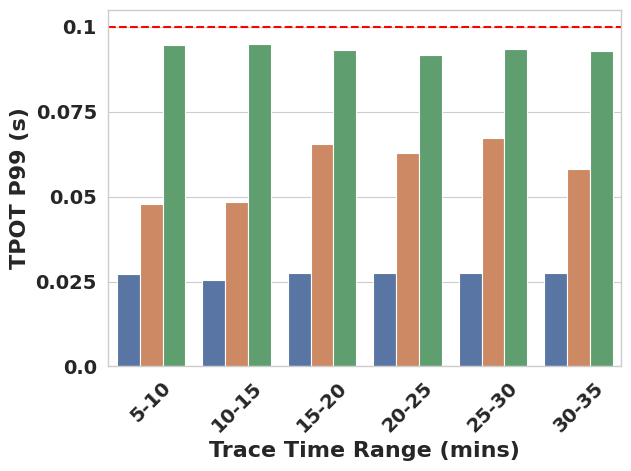

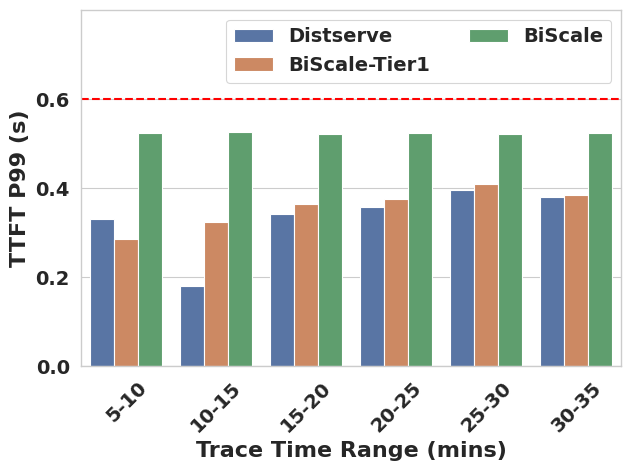

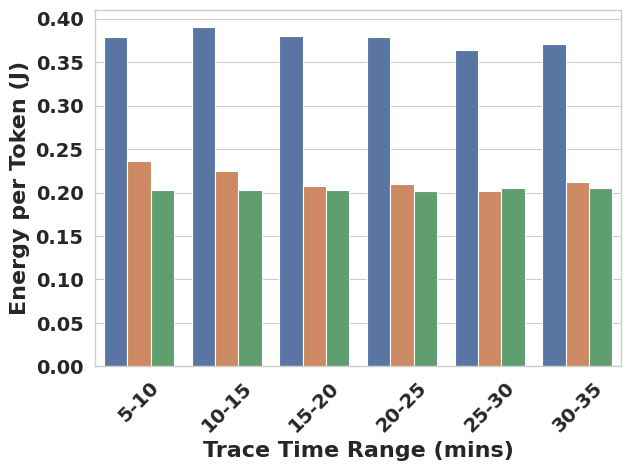

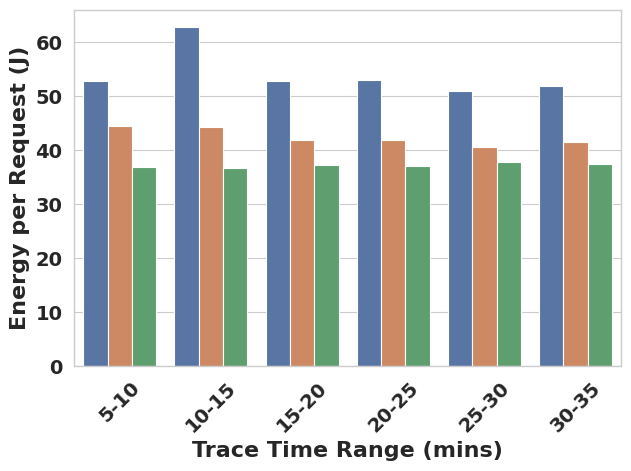

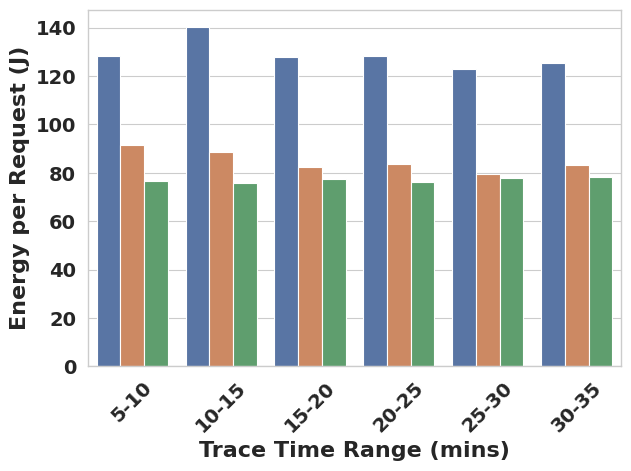

In [18]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance_dvfs_redo_together_ai/profiler_logs_0/metrics.csv'
df_results_together_ai_disag_dvfs = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq, df_results_together_ai_disag_dvfs])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'BiScale-Tier1 85',
    'OURS_R5_JAN3_OLD_P90_5': 'BiScale-Tier1 70',
    'OURS_R5_JAN3_OLD_P90_4': 'BiScale-Tier1 55',
    'OURS_R5_JAN3_OLD_P90_3': 'BiScale-Tier1 40',
    'OURS_R5_JAN3_OLD_P90_2': 'BiScale-Tier1 25',
    'OURS_R5_JAN3_OLD_P90_1': 'BiScale-Tier1 10',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_node0': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_node0': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_node0': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_node0': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_node0': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_node0': 'BiScale 85',
}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft.pdf", format="pdf")

############################ energy per token - decode #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_token_decode.pdf", format="pdf")

############################ energy per request - prefill #######################
df_results_dis = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_prefill.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total.pdf", format="pdf")

In [19]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)

df_results[['expr_dir', 'energy_per_token', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
36,Distserve 85,0.628895,0.000000,0.000000,-25.082967,-74.436022,0.000000
30,Distserve 70,0.619209,0.000000,0.000000,-25.394194,-80.501294,0.000000
24,Distserve 55,0.642644,0.000000,0.000000,-26.554869,-80.403935,0.000000
18,Distserve 40,0.643072,0.000000,0.000000,-25.794306,-82.787437,0.000000
12,Distserve 25,0.703284,0.000000,0.000000,-41.905471,-73.542155,0.000000
5,Distserve 10,0.640744,0.000000,0.000000,-18.915336,-60.385601,0.000000
148,BiScale-Tier1 85,0.420702,20.053063,42.672391,0.000000,0.000000,33.523529
127,BiScale-Tier1 70,0.409741,20.251491,44.598735,0.000000,0.000000,35.164921
106,BiScale-Tier1 55,0.419119,20.982890,44.568837,0.000000,0.000000,34.878087
85,BiScale-Tier1 40,0.420812,20.505146,45.291645,0.000000,0.000000,35.559194


/tmp/ipykernel_1464519/3543984730.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1464519/3543984730.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


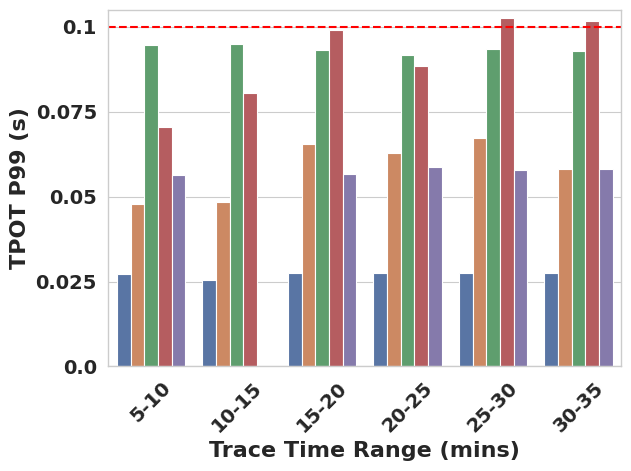

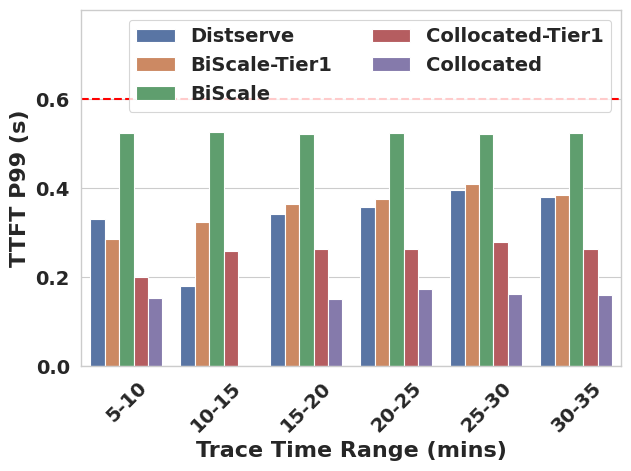

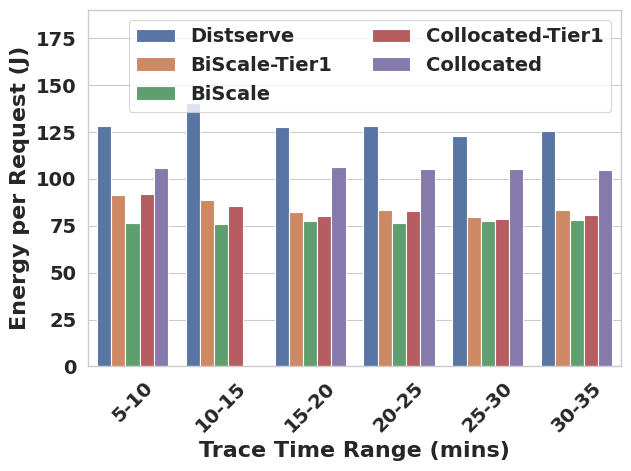

In [20]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance_dvfs_redo_together_ai/profiler_logs_0/metrics.csv'
df_results_together_ai_disag_dvfs = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq, df_results_together_ai_disag_dvfs])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'BiScale-Tier1 85',
    'OURS_R5_JAN3_OLD_P90_5': 'BiScale-Tier1 70',
    'OURS_R5_JAN3_OLD_P90_4': 'BiScale-Tier1 55',
    'OURS_R5_JAN3_OLD_P90_3': 'BiScale-Tier1 40',
    'OURS_R5_JAN3_OLD_P90_2': 'BiScale-Tier1 25',
    'OURS_R5_JAN3_OLD_P90_1': 'BiScale-Tier1 10',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_node0': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_node0': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_node0': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_node0': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_node0': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_node0': 'BiScale 85',
    'OURS_CHUNK_FEB24_REAL_P67_6_node0': 'Collocated-Tier1 85',
    'OURS_CHUNK_FEB24_REAL_P67_5_node0': 'Collocated-Tier1 70',
    'OURS_CHUNK_FEB24_REAL_P67_4_node0': 'Collocated-Tier1 55',
    'OURS_CHUNK_FEB24_REAL_P67_3_node0': 'Collocated-Tier1 40',
    'OURS_CHUNK_FEB24_REAL_P67_2_node0': 'Collocated-Tier1 25',
    'OURS_CHUNK_FEB24_REAL_P67_1_node0': 'Collocated-Tier1 10',
    'OURS_CHUNK_FEB24_REAL_P67_6_DVFS_node1': 'Collocated 85',
    'OURS_CHUNK_FEB24_REAL_P67_5_DVFS_node1': 'Collocated 70',
    'OURS_CHUNK_FEB24_REAL_P67_4_DVFS_node1': 'Collocated 55',
    'OURS_CHUNK_FEB24_REAL_P67_3_DVFS_node1': 'Collocated 40',
    'OURS_CHUNK_FEB24_REAL_P67_2DVFS_node1': 'Collocated 25',
    'OURS_CHUNK_FEB24_REAL_P67_1_DVFS_node1': 'Collocated 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot_w_coll.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft_w_coll_w_coll.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 190)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
# ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total_w_coll.pdf", format="pdf")


In [21]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_BT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_CT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Collocated-Tier1')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_req', 'energy_norm_D', 'energy_norm_BT1', 'energy_norm_CT1']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_req,energy_norm_D,energy_norm_BT1,energy_norm_CT1
36,Distserve 85,125.295542,0.000000,-49.486888,-55.160964
30,Distserve 70,122.868125,0.000000,-51.121944,-56.025795
24,Distserve 55,128.312231,0.000000,-53.332098,-55.050232
18,Distserve 40,127.821564,0.000000,-52.816817,-59.484400
12,Distserve 25,140.324565,0.000000,-56.976605,-64.274401
5,Distserve 10,128.111908,0.000000,-40.560737,-39.811603
29,Collocated-Tier1 85,80.751974,32.196626,-1.357154,0.000000
24,Collocated-Tier1 70,78.748597,33.910891,0.124854,0.000000
19,Collocated-Tier1 55,82.755266,33.360628,-2.179547,0.000000
14,Collocated-Tier1 40,80.146750,35.586573,1.565450,0.000000


/tmp/ipykernel_1464519/310152970.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1464519/310152970.py:117: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


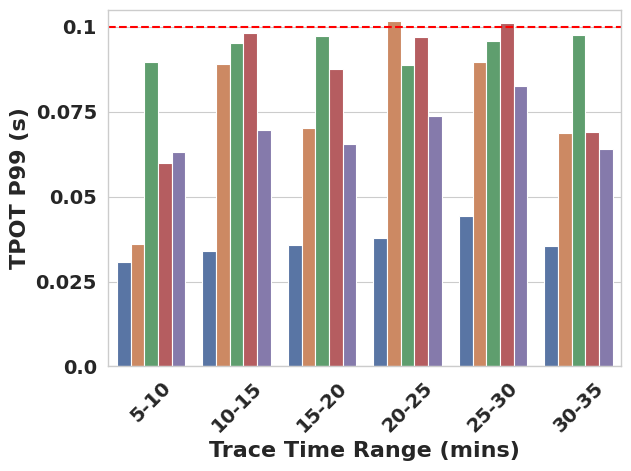

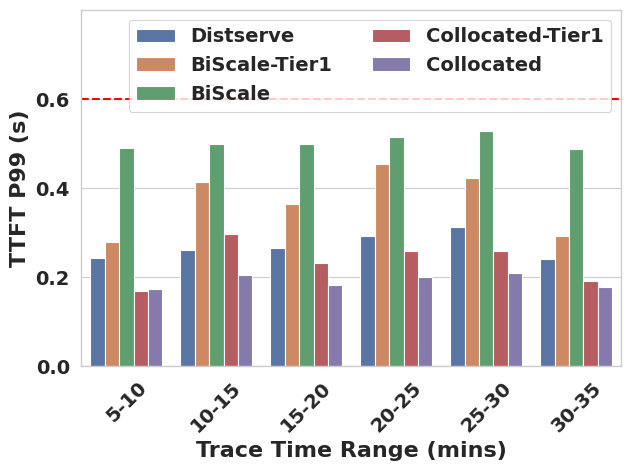

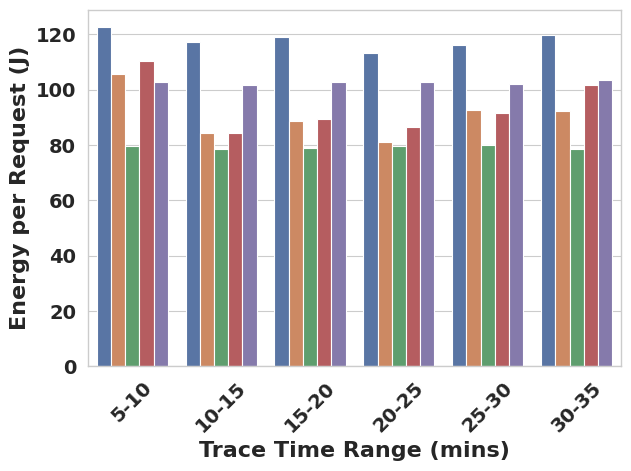

In [22]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS',
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'BiScale-Tier1 85',
    'OURS_R5_JAN3_REAL_P85_5': 'BiScale-Tier1 70',
    'OURS_R5_JAN3_REAL_P85_4': 'BiScale-Tier1 55',
    'OURS_R5_JAN3_REAL_P85_3': 'BiScale-Tier1 40',
    'OURS_R5_JAN3_REAL_P85_2': 'BiScale-Tier1 25',
    'OURS_R5_JAN3_REAL_P85_1': 'BiScale-Tier1 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'BiScale 10',
    'OURS_CHUNK_FEB24_REAL_P85_6_node0': 'Collocated-Tier1 85',
    'OURS_CHUNK_FEB24_REAL_P85_5_node0': 'Collocated-Tier1 70',
    'OURS_CHUNK_FEB24_REAL_P85_4_node0': 'Collocated-Tier1 55',
    'OURS_CHUNK_FEB24_REAL_P85_3_node0': 'Collocated-Tier1 40',
    'OURS_CHUNK_FEB24_REAL_P85_2_node0': 'Collocated-Tier1 25',
    'OURS_CHUNK_FEB24_REAL_P85_1_node0': 'Collocated-Tier1 10',
    'OURS_CHUNK_FEB24_REAL_P85_6_DVFS_node1': 'Collocated 85',
    'OURS_CHUNK_FEB24_REAL_P85_5_DVFS_node1': 'Collocated 70',
    'OURS_CHUNK_FEB24_REAL_P85_4_DVFS_node1': 'Collocated 55',
    'OURS_CHUNK_FEB24_REAL_P85_3_DVFS_node1': 'Collocated 40',
    'OURS_CHUNK_FEB24_REAL_P85_2_DVFS_node1': 'Collocated 25',
    'OURS_CHUNK_FEB24_REAL_P85_1_DVFS_node1': 'Collocated 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_85p_trace_tpot_w_coll.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/real_85p_trace_ttft_w_coll.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_85p_trace_energy_per_request_total_w_coll.pdf", format="pdf")


In [23]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_req', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_req,energy_norm_D
41,Distserve 85,119.614602,0.000000
34,Distserve 70,115.981639,0.000000
27,Distserve 55,113.264423,0.000000
20,Distserve 40,119.146984,0.000000
13,Distserve 25,117.004067,0.000000
6,Distserve 10,122.668755,0.000000
59,Collocated-Tier1 85,101.719447,14.960677
54,Collocated-Tier1 70,91.694129,20.940823
49,Collocated-Tier1 55,86.575678,23.563220
44,Collocated-Tier1 40,89.223811,25.114503


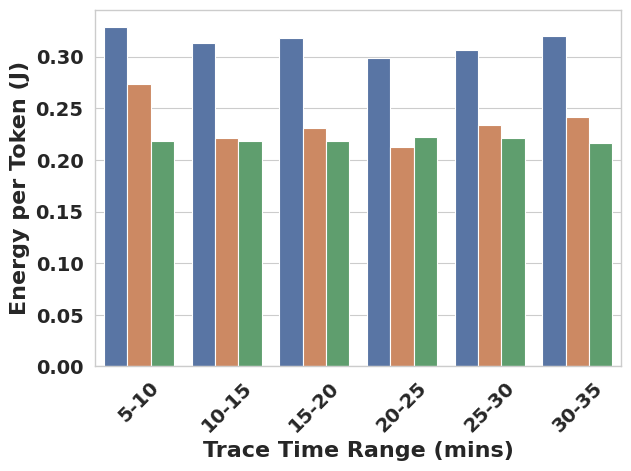

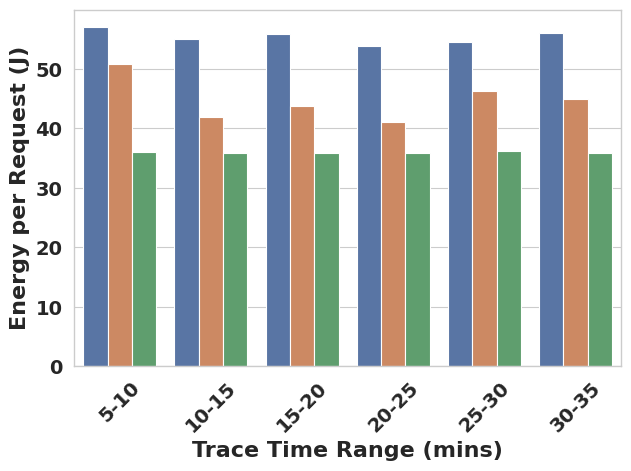

In [24]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS',
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'BiScale-Tier1 85',
    'OURS_R5_JAN3_REAL_P85_5': 'BiScale-Tier1 70',
    'OURS_R5_JAN3_REAL_P85_4': 'BiScale-Tier1 55',
    'OURS_R5_JAN3_REAL_P85_3': 'BiScale-Tier1 40',
    'OURS_R5_JAN3_REAL_P85_2': 'BiScale-Tier1 25',
    'OURS_R5_JAN3_REAL_P85_1': 'BiScale-Tier1 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'BiScale 10',
}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])


############################ energy per token - decode #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_85p_trace_energy_per_token_decode.pdf", format="pdf")

############################ energy per request - prefill #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_85p_trace_energy_per_request_prefill.pdf", format="pdf")